# EDA Interactive Notebook
# # 📊 Retail Exploratory Data Analysis

---

### How to use this notebook
Run cells from top to bottom using **Shift+Enter**.
Each cell has a comment explaining what it does and why.

This notebook is the **interactive layer** on top of `run.py`.
While `run.py` produces text reports, this notebook produces:
- Visual charts (histograms, box plots, scatter plots, heatmaps)
- Interactive exploration of specific findings
- Deeper investigation of anomalies

**Business questions we answer here:**
## Business Questions

### Question 1 — Revenue Performance
Which product categories and stores generate the highest revenue per sale?  
Which stores are underperforming relative to their category average?

> Answered using `groupby` rankings and `vs_category_avg` comparisons.  
> A negative `vs_category_avg` value flags an underperforming store.

---

### Question 2 — Discount Impact
Does offering higher discounts actually drive higher sales volume?  
Compute the **Pearson correlation** between `discount_pct` and `total_amount`.

> A negative correlation means higher discounts produce lower revenue totals —  
> the company is sacrificing margin without increasing sales.

---

### Question 3 — Anomaly Detection
Which transactions are statistically unusual?  
Use **IQR + Z-score consensus** to identify outliers and save them to `reports/anomalies.csv`.

> A transaction is flagged only when both methods agree — reducing false positives.



In [3]:
# ── Cell 1: Imports and Setup ─────────────────────────────────────────────
# Before anything else, we import the libraries we need.
# These are the standard imports for any EDA notebook.

import sys
import pathlib
import numpy as np

# Add the project root to Python path so we can import our classes
# pathlib.Path.cwd() returns the current working directory
# We walk up until we find config.py
_root = pathlib.Path.cwd()
while not (_root / 'config.py').exists() and _root != _root.parent:
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   # matplotlib: the core Python plotting library
import seaborn as sns             # seaborn: statistical plots built on matplotlib

# Tell matplotlib to display plots directly in the notebook (not in a separate window)



# Set seaborn style: 'whitegrid' adds a subtle grid which makes values easier to read
sns.set_style('whitegrid')

# Set figure size default: (width_inches, height_inches)
plt.rcParams['figure.figsize'] = (12, 5)

# Import our pipeline classes
from config import DATA_PATH, REPORTS_DIR, INDUSTRY
from src.eda_engine import EDAEngine
from src.anomaly_detector import AnomalyDetector
print(f'Setup complete. Industry: {INDUSTRY}')
print(f'Data file: {DATA_PATH}')


Setup complete. Industry: retail
Data file: /Users/samueladesina/retail-eda-analysis/data/processed-data.csv


In [4]:
# ── Cell 2: Load and Profile the Data ────────────────────────────────────
# We use our EDAEngine class to load and profile the data.
# This is the same code that run.py executes — but here we can
# inspect intermediate results interactively.

engine = EDAEngine()
engine.load().profile()

# Access the profile results dictionary directly
p = engine.results['profile']

print('=' * 50)
print('  DATASET OVERVIEW')
print('=' * 50)
print(f'  Rows:          {p["rows"]:,}')
print(f'  Columns:       {p["columns"]}')
print(f'  Numeric cols:  {p["numeric_cols"]}')
print(f'  Text cols:     {p["categorical_cols"]}')
print(f'  Missing vals:  {p["total_nulls"]:,} ({p["null_pct"]}%)')
print(f'  Memory:        {p["memory_mb"]} MB')

2026-05-16 23:38:32 [INFO] EDAEngine initialised — industry: retail
2026-05-16 23:38:32 [INFO] [EDA] Loading: processed-data.csv
2026-05-16 23:38:33 [INFO] [EDA] Loaded 50,243 rows × 33 columns
2026-05-16 23:38:33 [INFO] [EDA] Column types: 12 numeric, 14 categorical
2026-05-16 23:38:33 [INFO] [EDA] Computing dataset profile...
2026-05-16 23:38:34 [INFO] [EDA] Profile complete — 50,243 rows | 0.0% nulls


  DATASET OVERVIEW
  Rows:          50,243
  Columns:       33
  Numeric cols:  12
  Text cols:     14
  Missing vals:  0 (0.0%)
  Memory:        59.21 MB


In [5]:
# ── Cell 3: Descriptive Statistics ───────────────────────────────────────
# pandas .describe() gives us the 8 key statistics for every numeric column.
# We display it as a formatted table directly in the notebook.

# Select only columns that are not pipeline metadata (starting with _)
analysis_df = engine.df.drop(
    columns=[c for c in engine.df.columns if c.startswith('_')],
    errors='ignore'
)

# .describe() → count, mean, std, min, 25%, 50%, 75%, max for each numeric col
# .T transposes the table: columns become rows (easier to read with many columns)
# .style.background_gradient() adds colour — higher values are darker blue
desc = analysis_df.describe().round(2).T
desc

,count,mean,std,min,25%,50%,75%,max
sale_id,50243.0,24995.56,14439.15,1.00,12482.50,25002.00,37502.50,50007.00
quantity,50243.0,5.50,2.88,1.00,3.00,5.00,8.00,10.00
unit_price,50243.0,997.46,577.31,1.08,500.28,994.38,1498.92,1999.99
discount_pct,50243.0,7.04,7.27,0.00,0.00,5.00,15.00,20.00
total_amount,50243.0,5065.01,4274.88,-8664.95,1619.51,3889.74,7546.58,99999.99
product_id,50243.0,498.41,288.72,1.00,249.00,498.00,747.00,1000.00
unit_cost,50243.0,187.68,278.68,1.61,12.85,38.80,209.05,1393.61
margin_pct,50243.0,57.63,14.63,14.17,49.97,61.22,68.83,81.03
store_id,50243.0,6.98,3.74,1.00,4.00,7.00,10.00,13.00
sqft,50243.0,11594.21,3984.57,5000.00,9500.00,11000.00,13000.00,20000.00


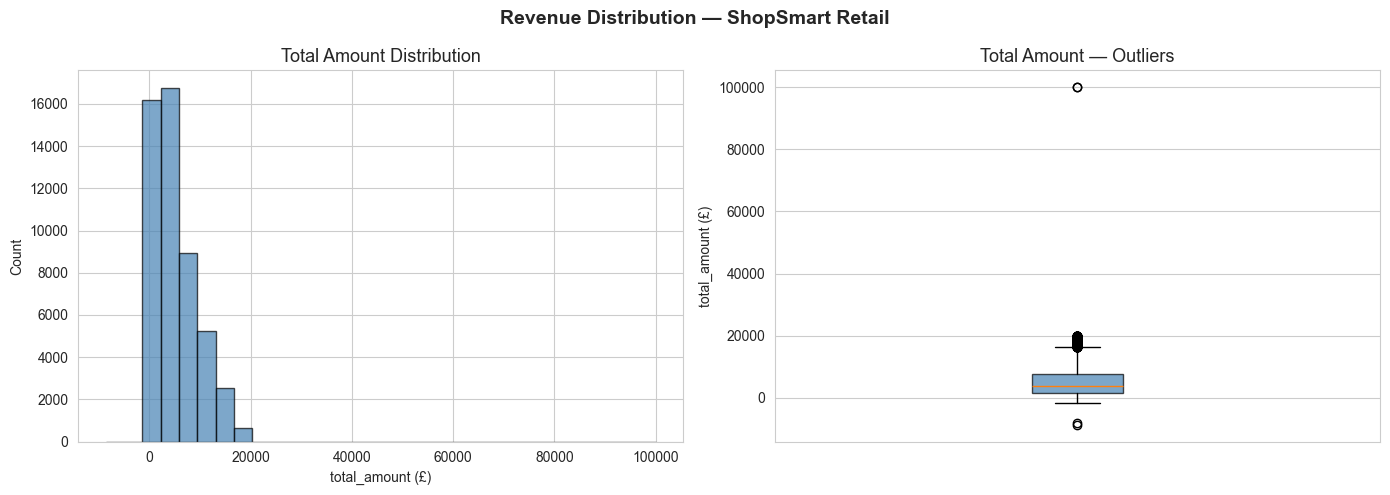

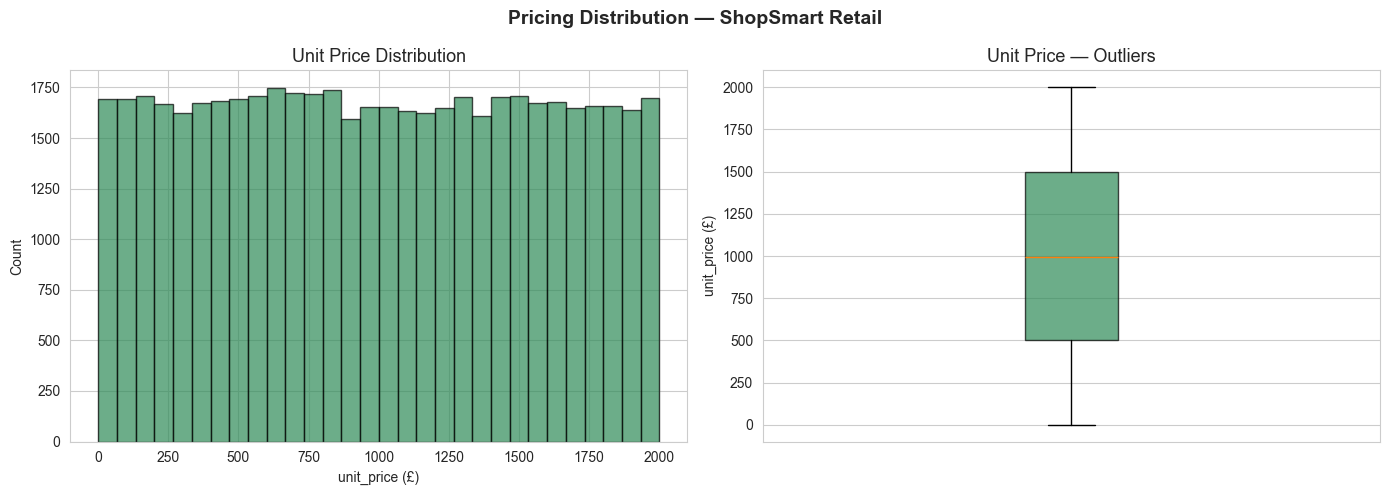

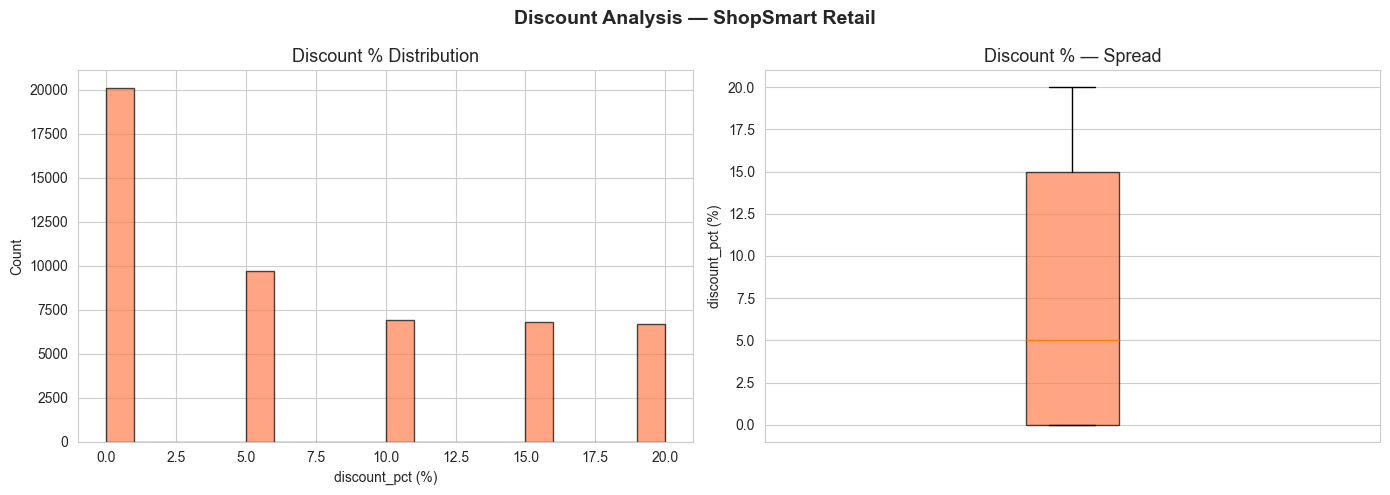

In [10]:
import numpy as np

# ── Total Amount Distribution — Histogram & Boxplot ──────────────────────
if 'total_amount' in analysis_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left plot: histogram
    axes[0].hist(
        analysis_df['total_amount'].dropna(),
        bins=30,
        color='steelblue',
        alpha=0.7,
        edgecolor='black'
    )
    axes[0].set_title('Total Amount Distribution', fontsize=13)
    axes[0].set_xlabel('total_amount (£)')
    axes[0].set_ylabel('Count')

    # Right plot: boxplot (reveals the negative outliers)
    axes[1].boxplot(
        analysis_df['total_amount'].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.7)
    )
    axes[1].set_title('Total Amount — Outliers', fontsize=13)
    axes[1].set_ylabel('total_amount (£)')
    axes[1].set_xticks([])

    plt.suptitle('Revenue Distribution — ShopSmart Retail', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ── Unit Price Distribution ───────────────────────────────────────────────
if 'unit_price' in analysis_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(
        analysis_df['unit_price'].dropna(),
        bins=30,
        color='seagreen',
        alpha=0.7,
        edgecolor='black'
    )
    axes[0].set_title('Unit Price Distribution', fontsize=13)
    axes[0].set_xlabel('unit_price (£)')
    axes[0].set_ylabel('Count')

    axes[1].boxplot(
        analysis_df['unit_price'].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='seagreen', alpha=0.7)
    )
    axes[1].set_title('Unit Price — Outliers', fontsize=13)
    axes[1].set_ylabel('unit_price (£)')
    axes[1].set_xticks([])

    plt.suptitle('Pricing Distribution — ShopSmart Retail', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ── Discount % Distribution ───────────────────────────────────────────────
if 'discount_pct' in analysis_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(
        analysis_df['discount_pct'].dropna(),
        bins=20,
        color='coral',
        alpha=0.7,
        edgecolor='black'
    )
    axes[0].set_title('Discount % Distribution', fontsize=13)
    axes[0].set_xlabel('discount_pct (%)')
    axes[0].set_ylabel('Count')

    axes[1].boxplot(
        analysis_df['discount_pct'].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='coral', alpha=0.7)
    )
    axes[1].set_title('Discount % — Spread', fontsize=13)
    axes[1].set_ylabel('discount_pct (%)')
    axes[1].set_xticks([])

    plt.suptitle('Discount Analysis — ShopSmart Retail', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

2026-05-17 00:01:04 [INFO] [EDA] Running group analysis...
2026-05-17 00:01:04 [INFO] [EDA] Group analysis: 2 grouping variables


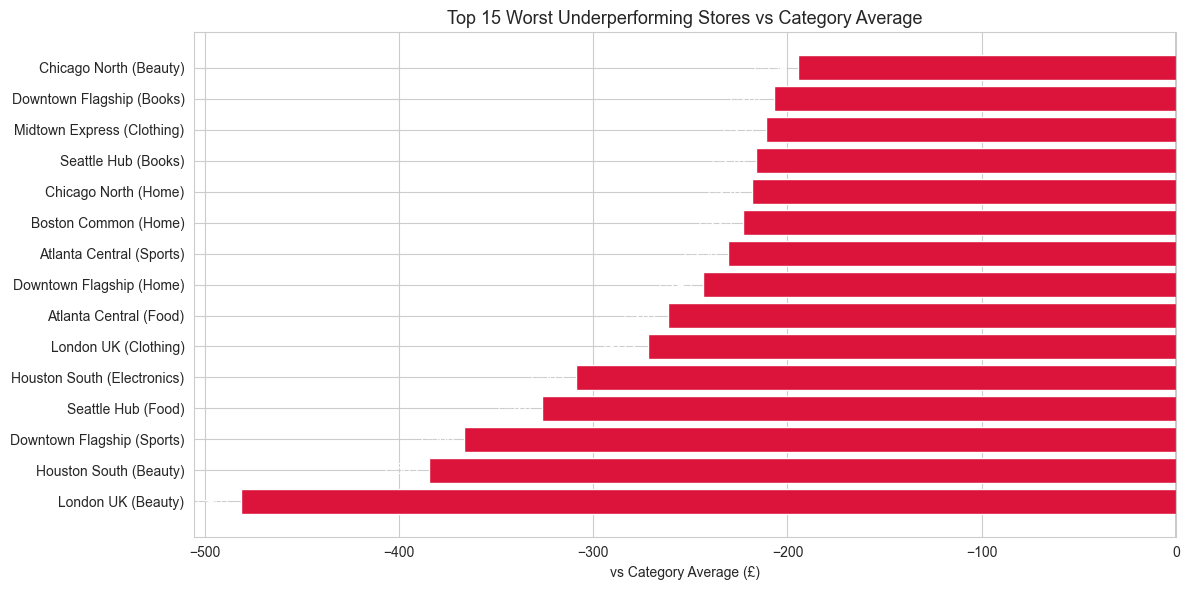


Top 15 worst performers:
       store_name    category  avg_per_sale  category_avg  vs_category_avg
        London UK      Beauty   4618.854813   5100.166812          -481.31
    Houston South      Beauty   4715.653689   5100.166812          -384.51
Downtown Flagship      Sports   4710.114678   5076.354435          -366.24
      Seattle Hub        Food   4672.554526   4998.846624          -326.29
    Houston South Electronics   4764.609886   5073.702256          -309.09
        London UK    Clothing   4830.445145   5102.316647          -271.87
  Atlanta Central        Food   4737.455052   4998.846624          -261.39
Downtown Flagship        Home   4776.921528   5020.306214          -243.38
  Atlanta Central      Sports   4845.858505   5076.354435          -230.50
    Boston Common        Home   4797.305747   5020.306214          -223.00
    Chicago North        Home   4801.888726   5020.306214          -218.42
      Seattle Hub       Books   4849.489876   5065.468003          -215.98

In [ ]:
# ── Cell 5: Q1 — Revenue Performance ─────────────────────────────────────
# Which product categories and stores generate the highest revenue per sale?
# Which stores are underperforming relative to their category average?

engine.group_analysis()

# ── Q1a: Top Categories by Revenue per Sale ───────────────────────────────
category_revenue = (
    analysis_df.groupby('category')['total_amount']
    .mean()
    .reset_index()
    .rename(columns={'total_amount': 'avg_revenue_per_sale'})
    .sort_values('avg_revenue_per_sale', ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(
    category_revenue['category'],
    category_revenue['avg_revenue_per_sale'],
    color=sns.color_palette('Blues_d', len(category_revenue))
)

for bar, val in zip(bars, category_revenue['avg_revenue_per_sale']):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            f'£{val:,.0f}', va='center', fontsize=11)

ax.set_title('Average Revenue per Sale by Category', fontsize=13)
ax.set_xlabel('Average Revenue per Sale (£)')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'q1_category_revenue_per_sale.png', dpi=150, bbox_inches='tight')
plt.show()

category_revenue_ranked = (
    category_revenue
    .sort_values('avg_revenue_per_sale', ascending=False)
    .reset_index(drop=True)
)
category_revenue_ranked.index += 1
category_revenue_ranked.columns = ['Category', 'Avg Revenue per Sale (£)']
category_revenue_ranked['Avg Revenue per Sale (£)'] = category_revenue_ranked['Avg Revenue per Sale (£)'].round(2)
print("CATEGORY RANKING — Highest Revenue per Sale")
print(category_revenue_ranked.to_string())


# ── Q1b: Top Stores by Revenue per Sale ───────────────────────────────────
store_revenue = (
    analysis_df.groupby('store_name')['total_amount']
    .mean()
    .reset_index()
    .rename(columns={'total_amount': 'avg_revenue_per_sale'})
    .sort_values('avg_revenue_per_sale', ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    store_revenue['store_name'],
    store_revenue['avg_revenue_per_sale'],
    color=sns.color_palette('Greens_d', len(store_revenue))
)

for bar, val in zip(bars, store_revenue['avg_revenue_per_sale']):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            f'£{val:,.0f}', va='center', fontsize=10)

ax.set_title('Average Revenue per Sale by Store', fontsize=13)
ax.set_xlabel('Average Revenue per Sale (£)')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'q1_store_revenue_per_sale.png', dpi=150, bbox_inches='tight')
plt.show()

store_revenue_ranked = (
    store_revenue
    .sort_values('avg_revenue_per_sale', ascending=False)
    .reset_index(drop=True)
)
store_revenue_ranked.index += 1
store_revenue_ranked.columns = ['Store', 'Avg Revenue per Sale (£)']
store_revenue_ranked['Avg Revenue per Sale (£)'] = store_revenue_ranked['Avg Revenue per Sale (£)'].round(2)
print("\nSTORE RANKING — Highest Revenue per Sale")
print(store_revenue_ranked.to_string())


# ── Q1c: Top 15 Worst Underperforming Stores vs Category Average ──────────
store_cat = (
    analysis_df.groupby(['store_name', 'category'])['total_amount']
    .mean()
    .reset_index()
    .rename(columns={'total_amount': 'avg_per_sale'})
)

cat_avg = analysis_df.groupby('category')['total_amount'].mean().rename('category_avg')
store_cat = store_cat.merge(cat_avg, on='category')
store_cat['vs_category_avg'] = (store_cat['avg_per_sale'] - store_cat['category_avg']).round(2)

underperforming = (
    store_cat[store_cat['vs_category_avg'] < 0]
    .sort_values('vs_category_avg')
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    underperforming['store_name'] + ' (' + underperforming['category'] + ')',
    underperforming['vs_category_avg'],
    color='crimson'
)

for bar, val in zip(bars, underperforming['vs_category_avg']):
    ax.text(val - 5, bar.get_y() + bar.get_height() / 2,
            f'£{val:,.0f}', va='center', ha='right', fontsize=10, color='white')

ax.axvline(0, color='black', linewidth=1)
ax.set_title('Top 15 Worst Underperforming Stores vs Category Average', fontsize=13)
ax.set_xlabel('vs Category Average (£)')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'q1_underperforming_stores.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop 15 worst underperforming store-category combinations:')
print(underperforming[['store_name', 'category', 'avg_per_sale', 'category_avg', 'vs_category_avg']]
      .to_string(index=False))